In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
BASE = '/content/drive/MyDrive/Text Miners/Actual Work'
print('Connected:', BASE)

Connected: /content/drive/MyDrive/Text Miners/Actual Work


In [3]:
!pip install scikit-learn==1.4 pandas numpy ftfy --quiet

In [4]:
import sklearn
import numpy as np
print(sklearn.__version__)
print(np.__version__)

1.4.0
1.26.4


In [5]:
!pip install wordcloud langdetect ftfy matplotlib seaborn --quiet

In [6]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/Text Miners/Actual Work'

import pandas as pd

df = pd.read_csv(f'{BASE}/data/raw_reviews.csv')
print('Shape:', df.shape)
print('\nColumn types:')
print(df.dtypes)
print('\nFirst 3 rows:')
df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (562365, 6)

Column types:
listing_id        int64
id                int64
date             object
reviewer_id       int64
reviewer_name    object
comments         object
dtype: object

First 3 rows:


,listing_id,id,date,reviewer_id,reviewer_name,comments
0,27934,1094339,2012-04-07,1368195,Michael,We stayed in the apartment for a week and we e...
1,27934,1241042,2012-05-07,2007324,Scott,My girlfriend and I recently stayed in Nuttee'...
2,27934,1523384,2012-06-20,2263352,Marc,I stayed for one month at the condo and was re...


In [9]:
print(df.columns.tolist())
print('\nFirst 3 rows:')
df.head(3)

['listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments', 'review_length']

First 3 rows:


,listing_id,id,date,reviewer_id,reviewer_name,comments,review_length
0,27934,1094339,2012-04-07,1368195,Michael,We stayed in the apartment for a week and we e...,98
1,27934,1241042,2012-05-07,2007324,Scott,My girlfriend and I recently stayed in Nuttee'...,123
2,27934,1523384,2012-06-20,2263352,Marc,I stayed for one month at the condo and was re...,199


In [10]:
# Null rates
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)

null_summary = pd.DataFrame({
    'Null Count': null_counts,
    'Null %': null_pct
})

print('=== Null Rate Analysis ===')
print(null_summary)

=== Null Rate Analysis ===
               Null Count  Null %
listing_id              0    0.00
id                      0    0.00
date                    0    0.00
reviewer_id             0    0.00
reviewer_name           6    0.00
comments               71    0.01
review_length           0    0.00


In [11]:
# Review length distribution
df['review_length'] = df['comments'].apply(lambda x: len(str(x).split()))

print('=== Review Length Stats ===')
print(df['review_length'].describe().round(2))

=== Review Length Stats ===
count    562365.00
mean         34.03
std          41.98
min           1.00
25%           5.00
50%          20.00
75%          47.00
max        1000.00
Name: review_length, dtype: float64


Nulls: 6 null reviewer names (negligible), 71 null comments (0.01%) — basically a clean dataset.
Review Length:

562,365 reviews counted ✅
Mean 34 words, Median 20 words — right-skewed, most reviews are short
Min 1 word — very short reviews exist, may need filtering in preprocessing
Max 1000 words — clear outlier

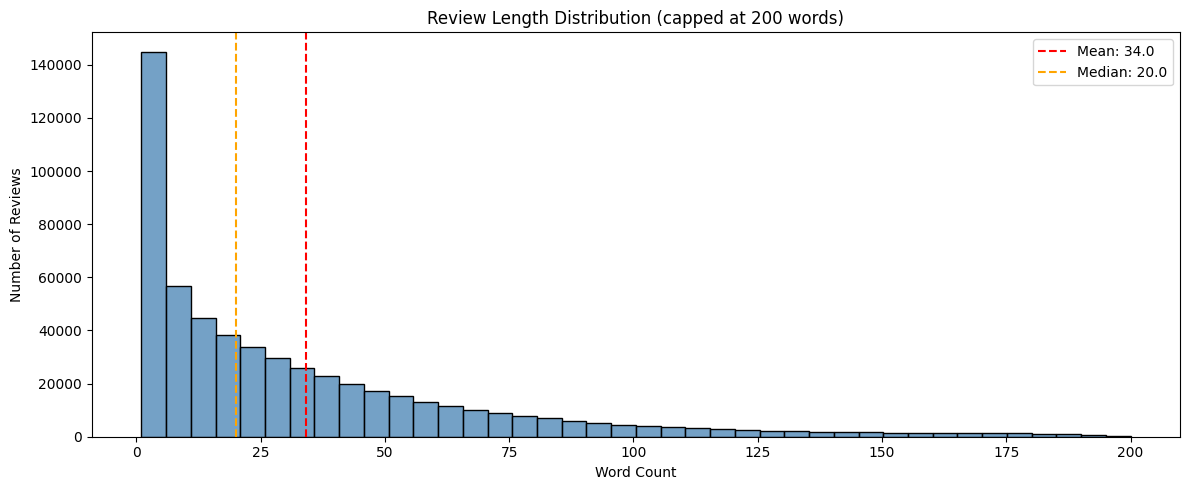

In [12]:
df = df.dropna(subset=['comments'])
df = df.reset_index(drop=True)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.histplot(df[df['review_length'] <= 200]['review_length'], bins=40, color='steelblue')

plt.title('Review Length Distribution (capped at 200 words)')
plt.xlabel('Word Count')
plt.ylabel('Number of Reviews')
plt.axvline(df['review_length'].mean(), color='red', linestyle='--', label=f"Mean: {df['review_length'].mean():.1f}")
plt.axvline(df['review_length'].median(), color='orange', linestyle='--', label=f"Median: {df['review_length'].median():.1f}")
plt.legend()
plt.tight_layout()
plt.show()

"Review lengths follow a right-skewed distribution. The majority of reviews are short (median 20 words), with a long tail extending to 1000 words. This is typical of hospitality review datasets where guests often leave brief impressions rather than detailed accounts."

In [13]:
# Average reviews per listing
reviews_per_listing = df.groupby('listing_id')['id'].count()

print('=== Reviews per Listing Stats ===')
print(reviews_per_listing.describe().round(2))

=== Reviews per Listing Stats ===
count    18385.00
mean        30.58
std         63.53
min          1.00
25%          3.00
50%          9.00
75%         32.00
max       2774.00
Name: id, dtype: float64


Reviews per Listing:

18,385 unique listings in the dataset
Mean 30.6 reviews, Median 9 — heavily skewed, most listings have few reviews but some have hundreds
Min 1, Max 2,774 — one listing has nearly 3k reviews, clear outlier
75% of listings have 32 or fewer reviews

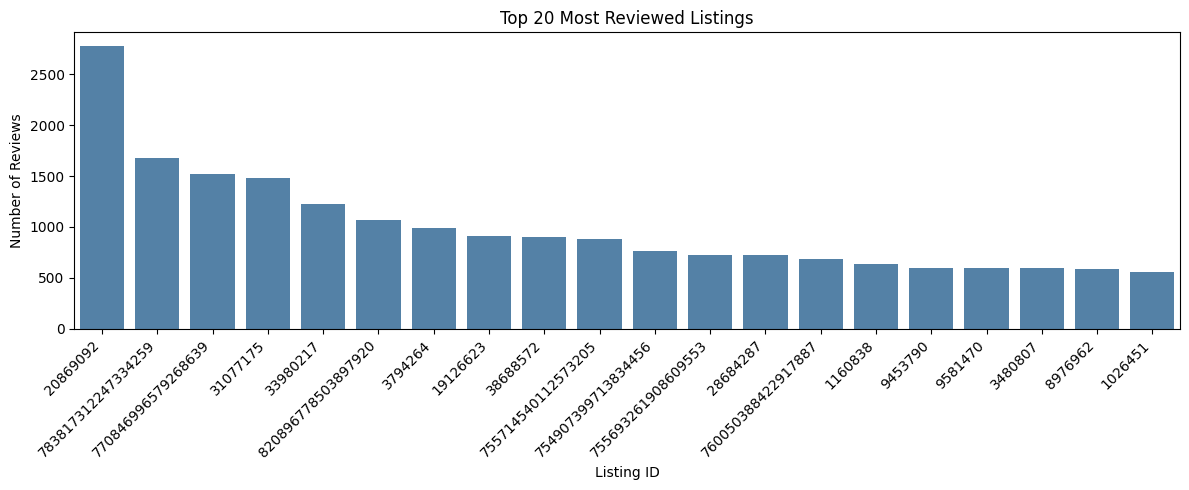

In [14]:
top20 = reviews_per_listing.sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 5))
sns.barplot(x=top20.index.astype(str), y=top20.values, color='steelblue')
plt.title('Top 20 Most Reviewed Listings')
plt.xlabel('Listing ID')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The drop-off after the first listing (2,774) is steep — that one listing has almost double the reviews of the second.

In [18]:
from langdetect import detect, LangDetectException, DetectorFactory
DetectorFactory.seed = 0

def detect_lang(text):
    try:
        return detect(str(text))
    except LangDetectException:
        return 'unknown'

df['lang'] = df['comments'].apply(detect_lang)

print('=== Language Breakdown ===')
print(df['lang'].value_counts().head(15))

=== Language Breakdown ===
lang
en         377237
zh-cn       59246
ko          29605
fr          19486
de          16800
ja           7504
zh-tw        6260
ru           6115
es           5299
th           4165
so           3816
ro           2862
unknown      2665
nl           2247
it           2238
Name: count, dtype: int64


Language Breakdown:

English: 377,237 (67%) — dominant but not overwhelming
Chinese (simplified): 59,246 (11%) — second largest
Korean: 29,605 (5%)
French: 19,486 (3%)
German: 16,800 (3%)
Remaining ~15% spread across Japanese, Russian, Spanish, Thai etc.

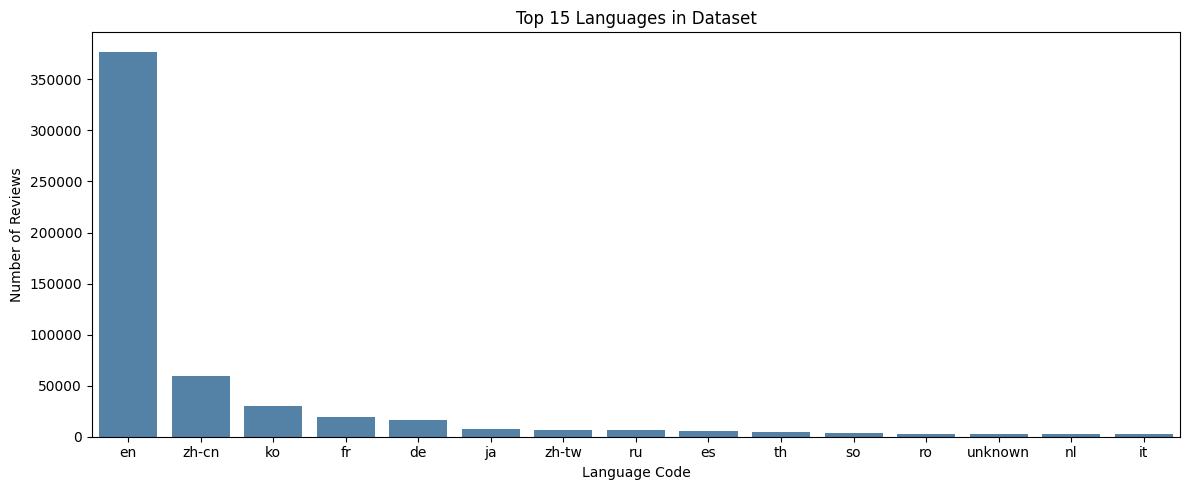

In [19]:
lang_counts = df['lang'].value_counts().head(15)

plt.figure(figsize=(12, 5))
sns.barplot(x=lang_counts.index, y=lang_counts.values, color='steelblue')
plt.title('Top 15 Languages in Dataset')
plt.xlabel('Language Code')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

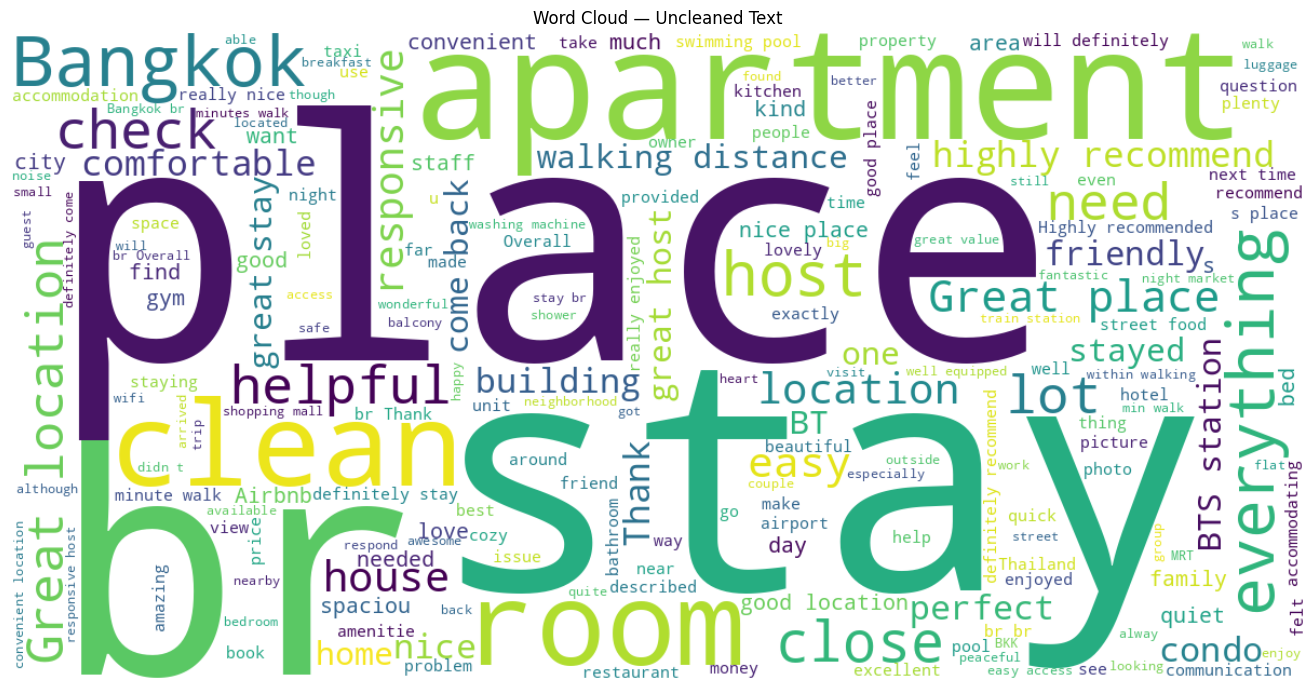

In [20]:
from wordcloud import WordCloud

text_uncleaned = ' '.join(df['comments'].astype(str).tolist())

wordcloud = WordCloud(width=1200, height=600, background_color='white', max_words=200).generate(text_uncleaned)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Uncleaned Text')
plt.tight_layout()
plt.show()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


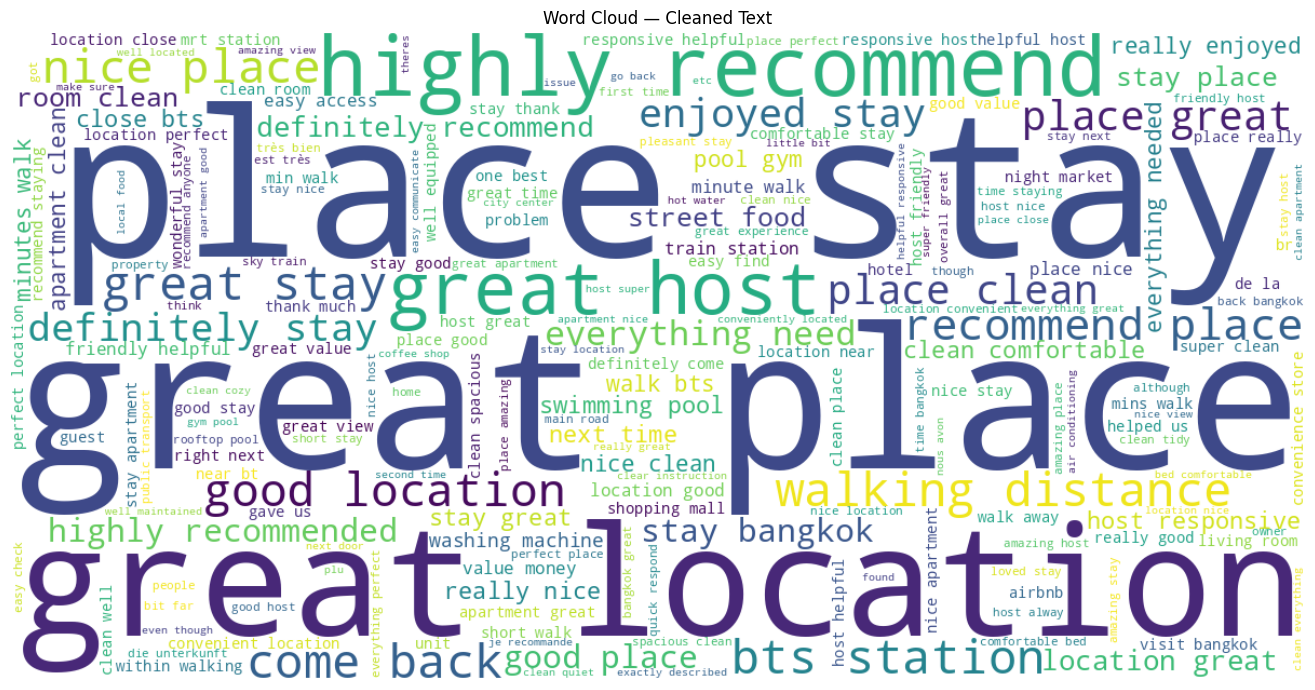

In [21]:
import nltk
from nltk.corpus import stopwords
import string

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and w.isalpha()]
    return ' '.join(tokens)

text_cleaned = ' '.join(df['comments'].apply(clean_text).tolist())

wordcloud_clean = WordCloud(width=1200, height=600, background_color='white', max_words=200).generate(text_cleaned)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud_clean, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Cleaned Text')
plt.tight_layout()
plt.show()

In [22]:
print('='*50)
print('KEY STATS SUMMARY — IS450 AirBnB Dataset')
print('='*50)

print(f'\n--- Overview ---')
print(f'Total reviews:              {len(df):,}')
print(f'Total unique listings:      {df["listing_id"].nunique():,}')
print(f'Total unique reviewers:     {df["reviewer_id"].nunique():,}')

print(f'\n--- Review Length ---')
print(f'Mean review length:         {df["review_length"].mean():.1f} words')
print(f'Median review length:       {df["review_length"].median():.1f} words')
print(f'Min review length:          {df["review_length"].min()} words')
print(f'Max review length:          {df["review_length"].max()} words')

print(f'\n--- Reviews per Listing ---')
rpl = df.groupby("listing_id")["id"].count()
print(f'Mean reviews per listing:   {rpl.mean():.1f}')
print(f'Median reviews per listing: {rpl.median():.1f}')
print(f'Max reviews per listing:    {rpl.max()}')

print(f'\n--- Data Quality ---')
print(f'Null comments:              {df["comments"].isnull().sum()}')
print(f'Null reviewer names:        {df["reviewer_name"].isnull().sum()}')

print(f'\n--- Language ---')
print(f'English reviews:            {(df["lang"] == "en").sum():,} ({(df["lang"] == "en").mean()*100:.1f}%)')
print(f'Non-English reviews:        {(df["lang"] != "en").sum():,} ({(df["lang"] != "en").mean()*100:.1f}%)')

print('\n' + '='*50)
print('Copy the above into the Dataset section of the report.')
print('='*50)

KEY STATS SUMMARY — IS450 AirBnB Dataset

--- Overview ---
Total reviews:              562,294
Total unique listings:      18,385
Total unique reviewers:     445,789

--- Review Length ---
Mean review length:         34.0 words
Median review length:       20.0 words
Min review length:          1 words
Max review length:          1000 words

--- Reviews per Listing ---
Mean reviews per listing:   30.6
Median reviews per listing: 9.0
Max reviews per listing:    2774

--- Data Quality ---
Null comments:              0
Null reviewer names:        6

--- Language ---
English reviews:            377,237 (67.1%)
Non-English reviews:        185,057 (32.9%)

Copy the above into the Dataset section of the report.


==================================================
KEY STATS SUMMARY — IS450 AirBnB Dataset
==================================================

--- Overview ---

Total reviews:              562,294

Total unique listings:      18,385

Total unique reviewers:     445,789

--- Review Length ---

Mean review length:         34.0 words

Median review length:       20.0 words

Min review length:          1 words

Max review length:          1000 words

--- Reviews per Listing ---

Mean reviews per listing:   30.6

Median reviews per listing: 9.0

Max reviews per listing:    2774

--- Data Quality ---

Null comments:              0

Null reviewer names:        6

--- Language ---

English reviews:            377,237 (67.1%)

Non-English reviews:        185,057 (32.9%)